In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [ ]:
X = 6 * np.random.rand(200,1)-3
y = 0.8 *X**2 + 0.9*X +2 + np.random.randn(200,1)

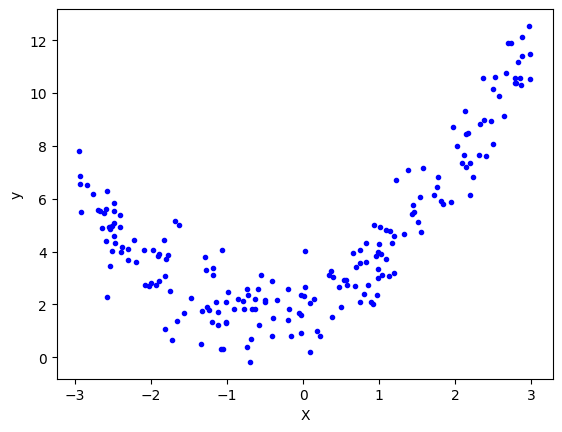

In [ ]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#Applying Linear Regression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.3975554363859156

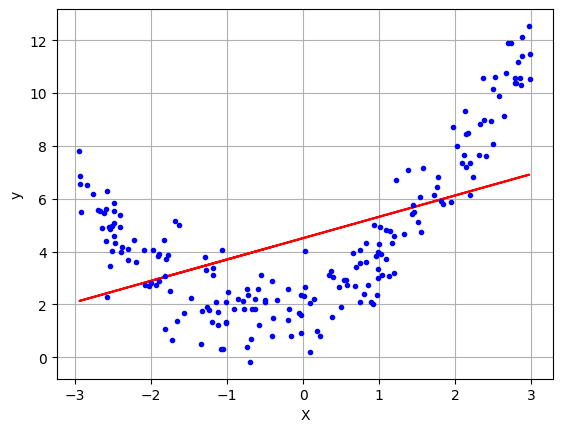

In [ ]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X,y,"b.")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [ ]:
# Applying Polynomial Linear Regression
poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [ ]:
print(X_train[0])
print(X_train_trans[0])

[-1.93985975]
[ 1.         -1.93985975  3.76305585]


In [ ]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_trans)

In [ ]:
r2_score(y_test,y_pred)

0.9308551611370459

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.93613743 0.80630919]]
[2.04259803]


In [ ]:
X_new =np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

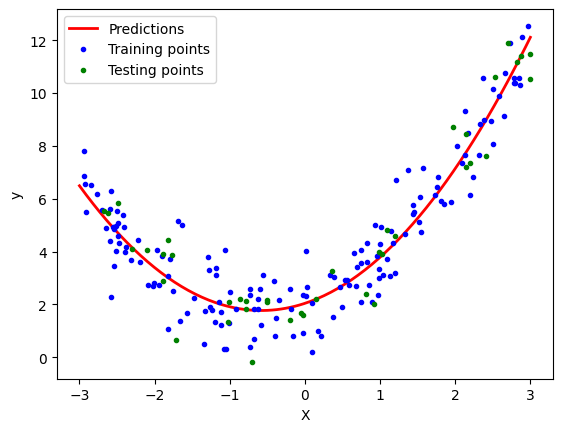

In [ ]:
plt.plot(X_new,y_new,"r-",linewidth=2,label ='Predictions')
plt.plot(X_train,y_train,"b.",label='Training points')
plt.plot(X_test,y_test,"g.",label='Testing points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# When we increase the degree

In [ ]:
poly1 = PolynomialFeatures(degree=15)

X_train_trans = poly1.fit_transform(X_train)
X_test_trans = poly1.transform(X_test)

In [ ]:
print(X_train[0])
print(X_train_trans[0])

[-1.93985975]
[ 1.00000000e+00 -1.93985975e+00  3.76305585e+00 -7.29980059e+00
  1.41605893e+01 -2.74695573e+01  5.32870886e+01 -1.03369478e+02
  2.00522291e+02 -3.88985121e+02  7.54576579e+02 -1.46377273e+03
  2.83951381e+03 -5.50825856e+03  1.06852491e+04 -2.07278846e+04]


In [ ]:
lr1 = LinearRegression()
lr1.fit(X_train_trans,y_train)

LinearRegression()

In [ ]:
y_pred1 = lr1.predict(X_test_trans)

In [ ]:
r2_score(y_test,y_pred1)

0.9136769920502589

In [ ]:
print(lr1.coef_)
print(lr1.intercept_)

[[ 0.00000000e+00  3.14490374e-01  7.56722256e-01  1.55506294e+00
   2.16504031e-01 -1.28489746e+00 -3.38062054e-03  5.45061125e-01
  -5.47521858e-02 -1.33174339e-01  1.77206657e-02  1.88386610e-02
  -2.09649817e-03 -1.42395786e-03  8.65110804e-05  4.42151954e-05]]
[1.95342253]


In [ ]:
X_new1 =np.linspace(-3,3,200).reshape(200,1)
X_new_poly1 = poly1.transform(X_new1)
y_new = lr1.predict(X_new_poly1)

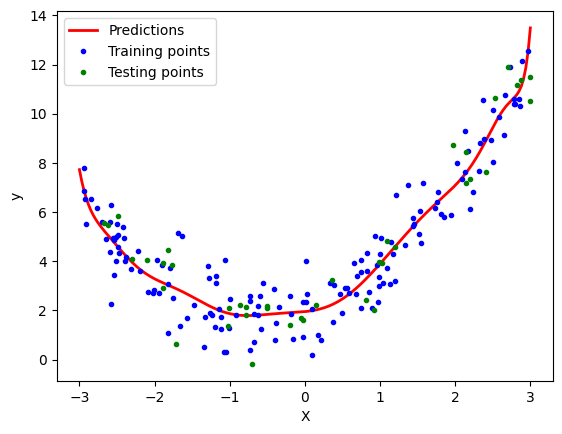

In [ ]:
plt.plot(X_new1,y_new,"r-",linewidth=2,label ='Predictions')
plt.plot(X_train,y_train,"b.",label='Training points')
plt.plot(X_test,y_test,"g.",label='Testing points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [ ]:
poly1 = PolynomialFeatures(degree=30)

X_train_trans = poly1.fit_transform(X_train)
X_test_trans = poly1.transform(X_test)

In [ ]:
lr1 = LinearRegression()
lr1.fit(X_train_trans,y_train)

LinearRegression()

In [ ]:
y_pred1 = lr1.predict(X_test_trans)

In [ ]:
r2_score(y_test,y_pred1)

0.7624058221279544

In [ ]:
X_new1 =np.linspace(-3,3,200).reshape(200,1)
X_new_poly1 = poly1.transform(X_new1)
y_new = lr1.predict(X_new_poly1)

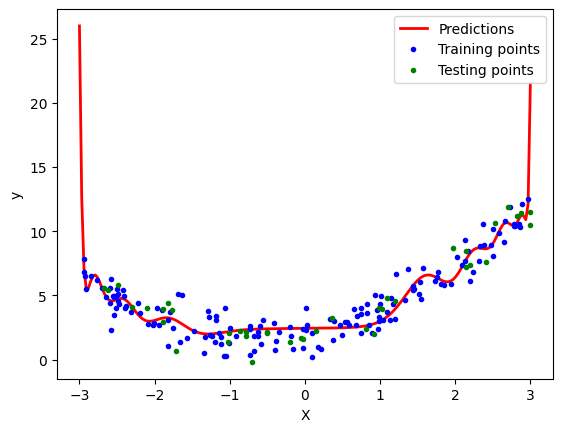

In [ ]:
plt.plot(X_new1,y_new,"r-",linewidth=2,label ='Predictions')
plt.plot(X_train,y_train,"b.",label='Training points')
plt.plot(X_test,y_test,"g.",label='Testing points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [ ]:
# 3D polynomial regression
x = 7*np.random.rand(100,1)-2.8
y = 7*np.random.rand(100,1)-2.8

z = x**2 + y**2 + 0.2*x + 0.2*y+0.1*x*y +2 +np.random.randn(100,1)

In [ ]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.show()

In [ ]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(),x.max(),10)
y_input = np.linspace(y.min(),y.max(),10)
xGrid ,yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

In [ ]:
import plotly.graph_objects as go

fig = px.scatter_3d(df,x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))

fig.show()

In [ ]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [ ]:
poly3 = PolynomialFeatures(degree =2)
X_multi_trans = poly3.fit_transform(X_multi)

In [ ]:
print("Output",poly3.n_output_features_)
print("Powers\n",poly3.powers_)

Output 6
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [ ]:
X_multi_trans.shape

(100, 6)

In [ ]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [ ]:
X_test_multi = poly3.transform(final)
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [ ]:
fig = px.scatter_3d(x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.update_layout(scene =dict(zaxis= dict(range=[0,35])))
fig.show()

# If we increase the Degree in 3D

In [ ]:
poly3 = PolynomialFeatures(degree =10)
X_multi_trans = poly3.fit_transform(X_multi)

In [ ]:
print("Output",poly3.n_output_features_)
print("Powers\n",poly3.powers_)

Output 66
Powers
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]]


In [ ]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [ ]:
X_test_multi = poly3.transform(final)
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [ ]:
fig = px.scatter_3d(x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(go.Surface(x=x_input,y=y_input,z=z_final))
fig.update_layout(scene =dict(zaxis= dict(range=[0,35])))
fig.show()